# Cell 1: Imports

In [131]:
import os
import sys
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# project paths
PROJECT_ROOT = r"D:\liver\CViMXAI"
SCRIPTS_DIR = os.path.join(PROJECT_ROOT, "scripts")
sys.path.append(SCRIPTS_DIR)

from models import ConvNeXtVisionMambaTabNet

# Cell 2: Configuration

In [ ]:
DATASET_NAME = "Lung_XRay"   # change to: Covid19_Ultrasound or Lung_XRay
NUM_CLASSES = 3

DATASET_PATHS = {
    "CXRay": r"D:\liver\CViMXAI\data\Covid-19_Chest_XRay",
    "Covid19_Ultrasound": r"D:\liver\CViMXAI\data\Covid19_Ultrasound",
    "Lung_XRay": r"D:\liver\CViMXAI\data\Lung_XRay",
    "ECG": r"D:\liver\CViMXAI\data\ECG_Data_balanced"
}

CLASS_NAMES = {
    "CXRay": ["COVID", "NORMAL", "PNEUMONIA"],
    "Covid19_Ultrasound": ["covid", "normal", "pneumonia"],
    "Lung_XRay": ["Lung_Opacity", "Normal", "Viral_Pneumonia"],
    "ECG": ["AHB", "Covid-19", "PMI", "Normal"]
}

FOLD = 5
BATCH_SIZE = 8
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

WEIGHT_PATH = os.path.join(
    PROJECT_ROOT,
    "weights",
    DATASET_NAME,
    f"best_model_fold_{FOLD}.pth"
)

SAVE_DIR = os.path.join(
    PROJECT_ROOT,
    "results",
    DATASET_NAME,
    "feature_importance"
)

os.makedirs(SAVE_DIR, exist_ok=True)

print("Using device:", DEVICE)
print("Weight path:", WEIGHT_PATH)

Using device: cuda
Weight path: D:\liver\CViMXAI\weights\Lung_XRay\best_model_fold_4.pth


# Cell 3: Dataset Loader

In [133]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

dataset = datasets.ImageFolder(
    root=DATASET_PATHS[DATASET_NAME],
    transform=transform
)

loader = DataLoader(
    dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print("Classes from ImageFolder:", dataset.classes)
print("Total images:", len(dataset))

Classes from ImageFolder: ['Lung_Opacity', 'Normal', 'Viral_Pneumonia']
Total images: 3475


# Cell 4: Load Trained Model

In [134]:
model = ConvNeXtVisionMambaTabNet(num_classes=NUM_CLASSES).to(DEVICE)
model.load_state_dict(torch.load(WEIGHT_PATH, map_location=DEVICE))
model.eval()

print("Model loaded successfully.")

Model loaded successfully.


# Cell 5: Extract Fused Features and Compute Importance

In [135]:
def compute_feature_importance(model, loader, device):
    """
    Computes gradient × input importance for fused features:
    ConvNeXt features + Vision Mamba features.
    """

    all_importance = []
    model.eval()

    for imgs, labels in loader:
        imgs = imgs.to(device)

        # ===== Extract features without storing gradients for backbones =====
        with torch.no_grad():
            c_feat = model.convnext(imgs)
            c_feat = torch.nn.functional.adaptive_avg_pool2d(c_feat, 1).flatten(1)

            v_feat = model.vision_mamba(imgs)

            fused_feat = torch.cat([c_feat, v_feat], dim=1)

        # Make fused feature a leaf tensor
        fused_feat = fused_feat.detach().clone().requires_grad_(True)

        # ===== Pass through TabNet-like module =====
        t_feat = model.tabnet(fused_feat)
        outputs = model.final_fc(t_feat)

        preds = torch.argmax(outputs, dim=1)
        selected_scores = outputs[torch.arange(outputs.size(0)), preds]

        model.zero_grad()

        if fused_feat.grad is not None:
            fused_feat.grad.zero_()

        selected_scores.sum().backward()

        # Gradient × input
        importance = torch.abs(fused_feat.grad * fused_feat)

        all_importance.append(importance.detach().cpu().numpy())

    all_importance = np.concatenate(all_importance, axis=0)
    mean_importance = np.mean(all_importance, axis=0)

    return mean_importance


importance = compute_feature_importance(model, loader, DEVICE)

print("Total fused features:", len(importance))
print("ConvNeXt features:", 1024)
print("Vision Mamba features:", 768)

Total fused features: 1792
ConvNeXt features: 1024
Vision Mamba features: 768


# Cell 6: Separate ConvNeXt and Vision Mamba Importance

In [136]:
convnext_importance = importance[:1024]
mamba_importance = importance[1024:]

convnext_total = convnext_importance.sum()
mamba_total = mamba_importance.sum()
total_importance = importance.sum()

convnext_percent = (convnext_total / total_importance) * 100
mamba_percent = (mamba_total / total_importance) * 100

print(f"ConvNeXt total features: 1024")
print(f"Vision Mamba total features: 768")
print(f"Total fused features: 1792")

print("\nFeature importance contribution:")
print(f"ConvNeXt contribution: {convnext_percent:.2f}%")
print(f"Vision Mamba contribution: {mamba_percent:.2f}%")

ConvNeXt total features: 1024
Vision Mamba total features: 768
Total fused features: 1792

Feature importance contribution:
ConvNeXt contribution: 97.02%
Vision Mamba contribution: 2.98%


# Cell 7: Save Feature Importance CSV

In [137]:
feature_names = []

for i in range(1024):
    feature_names.append(f"ConvNeXt_feature_{i+1}")

for i in range(768):
    feature_names.append(f"VisionMamba_feature_{i+1}")

df_importance = pd.DataFrame({
    "feature_name": feature_names,
    "feature_source": ["ConvNeXt"] * 1024 + ["Vision_Mamba"] * 768,
    "importance": importance
})

df_importance = df_importance.sort_values(
    by="importance",
    ascending=False
).reset_index(drop=True)

csv_path = os.path.join(SAVE_DIR, f"{DATASET_NAME}_fold_{FOLD}_feature_importance.csv")
df_importance.to_csv(csv_path, index=False)

print("Saved:", csv_path)

df_importance.head(20)

Saved: D:\liver\CViMXAI\results\Lung_XRay\feature_importance\Lung_XRay_fold_4_feature_importance.csv


,feature_name,feature_source,importance
0,ConvNeXt_feature_397,ConvNeXt,0.121930
1,ConvNeXt_feature_672,ConvNeXt,0.097119
2,ConvNeXt_feature_166,ConvNeXt,0.082581
3,ConvNeXt_feature_69,ConvNeXt,0.077925
4,ConvNeXt_feature_601,ConvNeXt,0.076754
5,ConvNeXt_feature_576,ConvNeXt,0.069468
6,ConvNeXt_feature_247,ConvNeXt,0.057252
7,ConvNeXt_feature_831,ConvNeXt,0.048593
8,ConvNeXt_feature_355,ConvNeXt,0.048391
9,ConvNeXt_feature_905,ConvNeXt,0.043327


# Cell 8: Save Source-Level Summary

In [138]:
summary_df = pd.DataFrame({
    "Feature_Source": ["ConvNeXt", "Vision Mamba"],
    "Number_of_Features": [1024, 768],
    "Total_Importance": [convnext_total, mamba_total],
    "Contribution_Percentage": [convnext_percent, mamba_percent]
})

summary_path = os.path.join(SAVE_DIR, f"{DATASET_NAME}_fold_{FOLD}_source_importance_summary.csv")
summary_df.to_csv(summary_path, index=False)

summary_df

,Feature_Source,Number_of_Features,Total_Importance,Contribution_Percentage
0,ConvNeXt,1024,11.268912,97.015941
1,Vision Mamba,768,0.346614,2.984054


# Cell 9: Plot Contribution Bar Chart

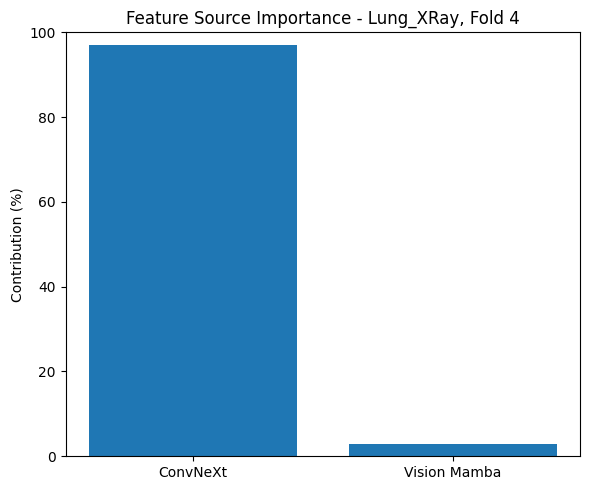

Saved: D:\liver\CViMXAI\results\Lung_XRay\feature_importance\Lung_XRay_fold_4_source_importance.png


In [139]:
plt.figure(figsize=(6, 5))
plt.bar(
    summary_df["Feature_Source"],
    summary_df["Contribution_Percentage"]
)

plt.ylabel("Contribution (%)")
plt.title(f"Feature Source Importance - {DATASET_NAME}, Fold {FOLD}")
plt.ylim(0, 100)
plt.tight_layout()

fig_path = os.path.join(SAVE_DIR, f"{DATASET_NAME}_fold_{FOLD}_source_importance.png")
plt.savefig(fig_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", fig_path)

# Cell 10: Plot Top 30 Selected Features

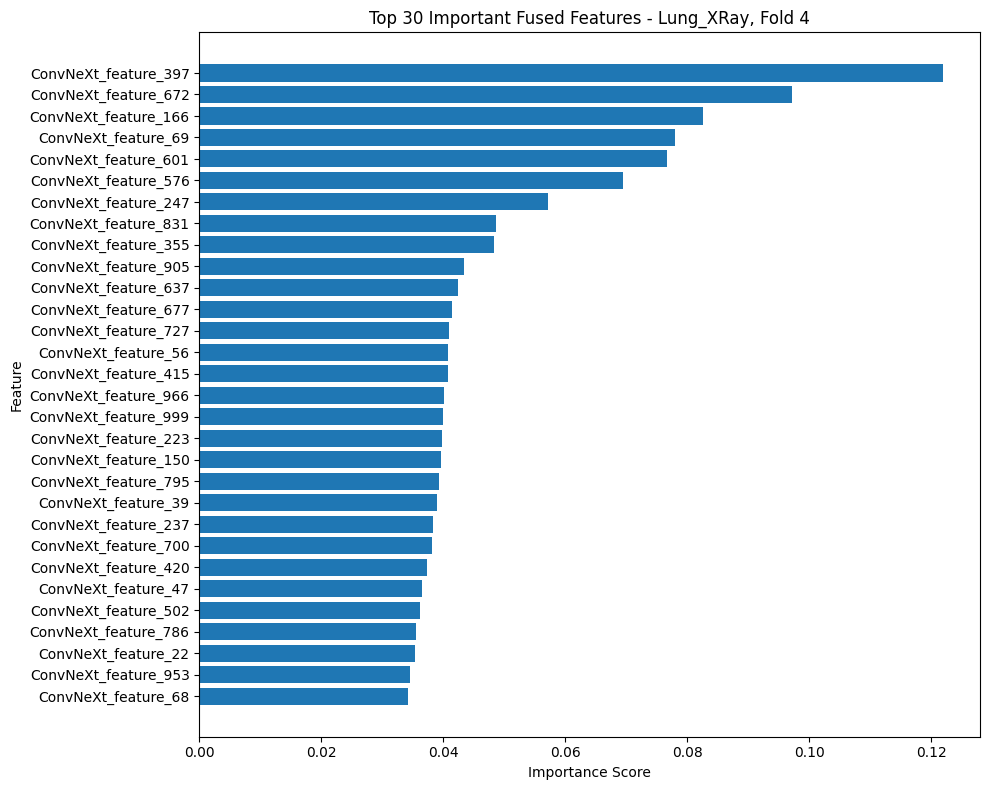

Saved: D:\liver\CViMXAI\results\Lung_XRay\feature_importance\Lung_XRay_fold_4_top_30_features.png


In [140]:
top_n = 30
top_df = df_importance.head(top_n)

plt.figure(figsize=(10, 8))
plt.barh(
    top_df["feature_name"][::-1],
    top_df["importance"][::-1]
)

plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.title(f"Top {top_n} Important Fused Features - {DATASET_NAME}, Fold {FOLD}")
plt.tight_layout()

fig_path = os.path.join(SAVE_DIR, f"{DATASET_NAME}_fold_{FOLD}_top_{top_n}_features.png")
plt.savefig(fig_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", fig_path)